Group Name: INT-Group8<br>
Group Memebrs:<br>
YU YIFAN - A191702<br>
YANG HANGYU - A204179<br>


scrapping target: https://warehouse-theme-metal.myshopify.com/collections/audio

GROUP PROJECT TTTC3213 (TOTAL 30 %)

 In this project, you are required to perform a complete ETL for any shopping/business website (in Malay or English language) in order to produce as simple analysis report.

First, start by setting the aim/goal of the project  e.g  ‘Report on the highest purchased laptop in Amazon.co website’ or ‘ The sentiment on newest iphone in Malaysia market'.

The same website are allowed to be scraped by different groups as long as the goal of the group’s project are different.

Identify related data need to be extracted and how they should be cleaned or transformed in order to generate your analysis report.
Project will be graded based on the following detail :

A. Data scraping

Pick/choose your website make sure it is legal to be scrapped.

Scrape your data  - identify and justify your chosen data.  (at least 2 attributes per member).

AT LEAST 100  or  more record of data are collected.

NOTE: All of those data scraped data should be based all the member’s assignments

B. Data cleaning and formatting

Perform any necessary data processing (cleaning/formatting); at least 4 types of data processing.

Perform at least 1 or more data visualisation ( e.g before and after data cleaning)

Perform at least 1 or more to visualise your project goal ( e.g % of positive sentiment etc)
NOTE: All of those data cleaning and formatting should be based all the member’s assignments.

C. Loading

Save your clean data into any type of file readable by pandas (e.g .csv, excel ) or SQL (based on labs).

**REPORT** (15%):

In the report, you should describe about:

Introduction on the business report ( the goal of your project) (2%)

Show how you scrape the data and explain why you choose the scrape the data ( include some snippet codes) (4%)

Show how you and explain why you choose certain data cleaning and data formatting (include visual) (4%)

Produce the project goal analysis ( include visual) (2%)

Make conclusion about the report (goal)  (1%)

 Give/shared link of your ETL codes via cloud (e.g Github) (2%)

For Dr Sabrina’s labs, please write in medium.com ( minus 5% will be deducted if not in medium.com)

Example of report in medium.com: https://medium.com/the-ttc3123-writers

SUBMIT your report (.pdf) / medium.com link to UKMFolio and your cleaned .csv file. Only the appointed GROUP LEADER will submit the project



According to the snippet given, the attributes that we are able to retrieve are 8, the rest is not showed because dynamic content(Review,Badge):

the 8 attributes are(item.container):


*   item title (name of the products)
*   item price
*   Inventory
*   Vendor
*   stars
*   link



# 1. EXTRACT (SCRAPPING)

In [1]:
#LIBRARY

!pip install requests beautifulsoup4
import pandas as pd
import re
pd.set_option('display.max_rows', None)
import numpy as np
import requests
from bs4 import BeautifulSoup

In [2]:
#Target

url = " https://warehouse-theme-metal.myshopify.com/collections/audio"
response = requests.get(url)

# Parse the page content with BeautifulSoup
soup = BeautifulSoup(response.text, 'html.parser')



In [3]:
print(soup.select("div.product-item")[0].prettify())

<div class="product-item product-item--vertical 1/3--tablet-and-up 1/4--desk">
 <a class="product-item__image-wrapper" href="/products/shure-srh440-professional-studio-headphones">
  <div class="aspect-ratio aspect-ratio--square" style="padding-bottom: 100.0%">
   <img alt="Shure SRH440 Professional Studio Headphones" class="product-item__primary-image" data-media-id="2748979970099" height="1378" loading="lazy" sizes="(max-width: 699px) 100vw, 600px" src="//warehouse-theme-metal.myshopify.com/cdn/shop/products/12405_976__2_2139873a-527f-4c6c-9e7c-be6aa0eacbe4.jpg?v=1559126290&amp;width=1378" srcset="//warehouse-theme-metal.myshopify.com/cdn/shop/products/12405_976__2_2139873a-527f-4c6c-9e7c-be6aa0eacbe4.jpg?v=1559126290&amp;width=200 200w, //warehouse-theme-metal.myshopify.com/cdn/shop/products/12405_976__2_2139873a-527f-4c6c-9e7c-be6aa0eacbe4.jpg?v=1559126290&amp;width=300 300w, //warehouse-theme-metal.myshopify.com/cdn/shop/products/12405_976__2_2139873a-527f-4c6c-9e7c-be6aa0eacbe4.j

In [32]:
def extract_star_rating(card):
    """
    Extract star rating from product card.
    If rating is not available, return default value 0.0
    """
    rating_elem = card.select_one(".rating")

    if not rating_elem:
        return "0.0", 0.0

    aria = rating_elem.get("aria-label")
    if aria:
        match = re.search(r"(\d+\.?\d*)", aria)
        if match:
            value = float(match.group(1))
            return f"{value:.1f}", value

    data_rating = rating_elem.get("data-rating")
    if data_rating:
        try:
            value = float(data_rating)
            return f"{value:.1f}", value
        except:
            pass

    return "0.0", 0.0


In [99]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import re

# ===============================
# Helper Functions
# ===============================

def clean_vendor(vendor):
    if not vendor or vendor == "N/A":
        return "unknown"
    return vendor.lower().strip()

def extract_star_rating(card):
    """Extract full + half stars and calculate rating."""
    star_elem = card.select_one("div.rating__stars")
    if not star_elem:
        return "N/A", 0

    # Full stars
    full_stars = len(star_elem.select("svg.rating__star--full"))

    # Half stars
    half_stars = len(star_elem.select("svg.rating__star--half"))

    rating_value = full_stars + (0.5 * half_stars)

    return f"{rating_value:.1f}", rating_value

# ===============================
# EXTRACT PROCESS
# ===============================

base_url = "https://warehouse-theme-metal.myshopify.com/collections/audio?page="
headers = {"User-Agent": "Mozilla/5.0"}

data = []

for page in range(1, 8):  # enough for 100+ records
    url = base_url + str(page)
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, "html.parser")

    product_cards = soup.select("div.product-item")

    for card in product_cards:

        # ===== PRODUCT NAME =====
        name_elem = card.select_one(".product-item__title")
        item_title = name_elem.get_text(strip=True) if name_elem else None

        # ===== PRICE =====
        price_elem = card.select_one(".price")
        price = price_elem.get_text(strip=True) if price_elem else None

        # ===== INVENTORY =====
        inventory_elem = card.select_one(".product-item__inventory")
        inventory = inventory_elem.get_text(strip=True) if inventory_elem else "in stock"

        # ===== VENDOR =====
        vendor_elem = card.select_one(".product-item__vendor")
        vendor_raw = vendor_elem.get_text(strip=True) if vendor_elem else "N/A"
        vendor = clean_vendor(vendor_raw)

        # ===== STAR RATING =====
        star_raw, stars = extract_star_rating(card)

        # ===== PRODUCT LINK =====
        link_elem = card.select_one(".product-item__title")
        link = (
            "https://warehouse-theme-metal.myshopify.com" + link_elem["href"]
            if link_elem else None
        )

        data.append([
            item_title,
            price,
            inventory,
            vendor,
            stars,
            link
        ])

    time.sleep(1)

df_raw = pd.DataFrame(
    data,
    columns=["item_title", "price", "inventory", "vendor", "stars", "link"]
)


print("Total records:", len(df_raw))
df_raw.head()

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

df_raw




Total records: 147


,item_title,price,inventory,vendor,stars,link
0,Shure SRH440 Professional Studio Headphones,Sale price$99.00,"In stock, 64 units",shure,4.5,https://warehouse-theme-metal.myshopify.com/pr...
1,JBL Flip 4 Waterproof Portable Bluetooth Speaker,Sale price$74.95,"In stock, 672 units",jbl,5.0,https://warehouse-theme-metal.myshopify.com/pr...
2,AKG N20U Premium In-Ear Headphones,Sale price$129.95,"In stock, 141 units",akg,4.5,https://warehouse-theme-metal.myshopify.com/pr...
3,Shure SB900A Lithium-Ion Rechargeable Battery,Sale price$118.00,"In stock, 148 units",shure,5.0,https://warehouse-theme-metal.myshopify.com/pr...
4,Pioneer PL-990 Automatic Stereo Turntable,Sale price$179.00,"In stock, 148 units",pioneer,3.0,https://warehouse-theme-metal.myshopify.com/pr...
5,Klipsch R6m In-Ear Headphones,Sale price$99.00,"In stock, 10 units",klipsch,4.0,https://warehouse-theme-metal.myshopify.com/pr...
6,JBL Go2 Portable Bluetooth Speaker,Sale price$39.95,"In stock, 798 units",jbl,4.5,https://warehouse-theme-metal.myshopify.com/pr...
7,Sony PS-HX500 Hi-Res USB Turntable,Sale price$398.00,"In stock, 15 units",sony,4.5,https://warehouse-theme-metal.myshopify.com/pr...
8,Sony NW-E395 Walkman Audio Player,Sale priceFrom $93.00,"In stock, 341 units",sony,5.0,https://warehouse-theme-metal.myshopify.com/pr...
9,Sennheiser Urbanite On-Ear Headphones,Sale price$199.95,"In stock, 43 units",sennheiser,5.0,https://warehouse-theme-metal.myshopify.com/pr...


In [56]:
# Create CSV
df.to_csv("shopify_sales_products.csv", index=False)


We need to change the datatype accordingly to its attribute




# 2. TRANSFORM (SCRAPPING)

First step is done, the data looks messy isnt it? we dont want the data scientist drive crazy just because we give the not clean data.. we need to make it NEAT!

**Cleaning Task1:** Inventory Numeric Cleaning

Ensure inventory contains numbers only

Handle missing values and remove any unwanted text

**Cleaning Task2:** Price Numeric Cleaning

Ensure price contains numbers only

Convert from string to float

**Cleaning Task3:** Vendor Name Standardization

Standardize vendor names to lowercase

Remove extra spaces or irrelevant characters

**Cleaning Task4:** Handling Missing Values

**Cleaning Task5:** Change the datatype accordingly to each attribute













In [10]:

import pandas as pd

df = df_raw.copy()

df["price"] = df["price"].astype(str)
df["price"] = df["price"].str.replace(r"[^0-9.]", "", regex=True)
df["price"] = pd.to_numeric(df["price"], errors="coerce").fillna(0.0)

df["inventory"] = df["inventory"].astype(str)
df["inventory"] = df["inventory"].str.replace(r"[^0-9]", "", regex=True)
df["inventory"] = pd.to_numeric(df["inventory"], errors="coerce").fillna(0).astype(int)

text_cols = ["item_title", "vendor", "link"]
for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

df = df.drop_duplicates(subset=["item_title", "link"])

print("Data types after transform:")
print(df.dtypes)
print("\nSample transformed data:")
print(df.head())


Data types after transform:
item_title     object
price         float64
inventory       int64
vendor         object
stars         float64
link           object
dtype: object

Sample transformed data:
                                         item_title   price  inventory  \
0       Shure SRH440 Professional Studio Headphones   99.00         64   
1  JBL Flip 4 Waterproof Portable Bluetooth Speaker   74.95        672   
2                AKG N20U Premium In-Ear Headphones  129.95        141   
3     Shure SB900A Lithium-Ion Rechargeable Battery  118.00        148   
4         Pioneer PL-990 Automatic Stereo Turntable  179.00        148   

    vendor  stars                                               link  
0    shure    4.5  https://warehouse-theme-metal.myshopify.com/pr...  
1      jbl    5.0  https://warehouse-theme-metal.myshopify.com/pr...  
2      akg    4.5  https://warehouse-theme-metal.myshopify.com/pr...  
3    shure    5.0  https://warehouse-theme-metal.myshopify.com/pr...  


In [11]:
df_raw = pd.DataFrame(
    data,
    columns=["item_title", "price", "inventory", "vendor", "stars", "link"]
)

print("Total records (raw):", len(df_raw))
df_raw.head()

df = df_raw.copy()

df["price"] = df["price"].astype(str).str.replace(r"[^0-9.]", "", regex=True)
df["price"] = pd.to_numeric(df["price"], errors="coerce").fillna(0.0)

df["inventory"] = df["inventory"].astype(str).str.replace(r"[^0-9]", "", regex=True)
df["inventory"] = pd.to_numeric(df["inventory"], errors="coerce").fillna(0).astype(int)

text_cols = ["item_title", "vendor", "link"]
for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

df = df.drop_duplicates(subset=["item_title", "link"])

output_file = "shopify_sales_products_cleaned.csv"
df.to_csv(output_file, index=False)
print(f"Total records (after transform & dedup): {len(df)}")
print(f"Data saved to {output_file}")

print("Total records:", len(df))
df.head()

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

df


Total records (raw): 147
Total records (after transform & dedup): 147
Data saved to shopify_sales_products_cleaned.csv
Total records: 147


,item_title,price,inventory,vendor,stars,link
0,Shure SRH440 Professional Studio Headphones,99.00,64,shure,4.5,https://warehouse-theme-metal.myshopify.com/pr...
1,JBL Flip 4 Waterproof Portable Bluetooth Speaker,74.95,672,jbl,5.0,https://warehouse-theme-metal.myshopify.com/pr...
2,AKG N20U Premium In-Ear Headphones,129.95,141,akg,4.5,https://warehouse-theme-metal.myshopify.com/pr...
3,Shure SB900A Lithium-Ion Rechargeable Battery,118.00,148,shure,5.0,https://warehouse-theme-metal.myshopify.com/pr...
4,Pioneer PL-990 Automatic Stereo Turntable,179.00,148,pioneer,3.0,https://warehouse-theme-metal.myshopify.com/pr...
5,Klipsch R6m In-Ear Headphones,99.00,10,klipsch,4.0,https://warehouse-theme-metal.myshopify.com/pr...
6,JBL Go2 Portable Bluetooth Speaker,39.95,798,jbl,4.5,https://warehouse-theme-metal.myshopify.com/pr...
7,Sony PS-HX500 Hi-Res USB Turntable,398.00,15,sony,4.5,https://warehouse-theme-metal.myshopify.com/pr...
8,Sony NW-E395 Walkman Audio Player,93.00,341,sony,5.0,https://warehouse-theme-metal.myshopify.com/pr...
9,Sennheiser Urbanite On-Ear Headphones,199.95,43,sennheiser,5.0,https://warehouse-theme-metal.myshopify.com/pr...


# 3. DATA VISUALIZATION

In [12]:
import matplotlib.pyplot as plt

<font size = 5>**Cleaning Task 1:**
Inventory Numeric Cleaning

Ensure inventory contains numbers only

Handle missing values and remove any unwanted text

<font size = 5>Before Cleaning:

This histogram shows the distribution of product prices before cleaning. Many prices include unwanted characters or missing values, making the data inconsistent. The distribution appears scattered, with some extremely high prices visible as potential outliers. These outliers may skew any statistical analysis if not cleaned.

In [85]:
df_before = df_raw[['inventory']].head(5)

df_before

,inventory
0,"In stock, 64 units"
1,"In stock, 672 units"
2,"In stock, 141 units"
3,"In stock, 148 units"
4,"In stock, 148 units"


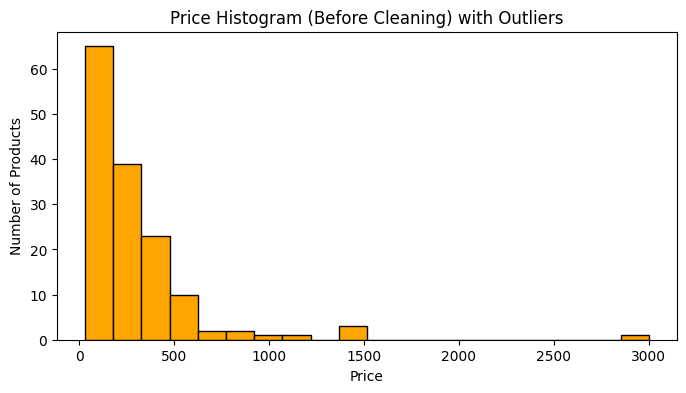

Outliers in Price (Before Cleaning):
[ 699.99 1499.   1199.   2999.   1499.    799.    699.    799.   1499.95
  999.95]


In [33]:
import pandas as pd
import matplotlib.pyplot as plt

df_raw = pd.read_csv("shopify_sales_products.csv")
price_raw = df_raw["price"].astype(str).str.replace(r"[^0-9.]", "", regex=True).replace("", "0").astype(float)

# Identify outliers using IQR
Q1 = price_raw.quantile(0.25)
Q3 = price_raw.quantile(0.75)
IQR = Q3 - Q1
outliers = price_raw[(price_raw < Q1 - 1.5*IQR) | (price_raw > Q3 + 1.5*IQR)]

plt.figure(figsize=(8,4))
plt.hist(price_raw, bins=20, color="orange", edgecolor="black")
plt.title("Price Histogram (Before Cleaning) with Outliers")
plt.xlabel("Price")
plt.ylabel("Number of Products")
plt.show()

print("Outliers in Price (Before Cleaning):")
print(outliers.values)


<font size = 5>After Cleaning:

After cleaning, the price data contains numbers only and missing values have been handled. The histogram now shows a more consistent distribution. The extreme outliers from the raw data have been removed or corrected, providing a cleaner dataset suitable for analysis.

In [88]:
df_after = df_raw[['inventory']].head(5).copy()

df_after['inventory'] = df_after['inventory'].str.extract(r'(\d+)')

df_after

,inventory
0,64
1,672
2,141
3,148
4,148


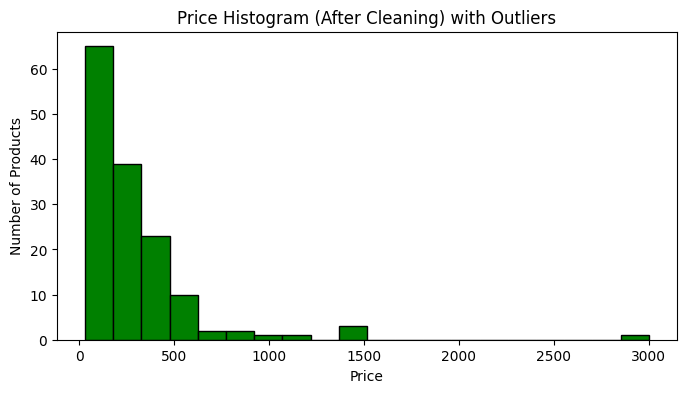

Outliers in Price (After Cleaning):
[ 699.99 1499.   1199.   2999.   1499.    799.    699.    799.   1499.95
  999.95]


In [34]:
df_clean = pd.read_csv("shopify_sales_products_cleaned.csv")
price_clean = df_clean["price"].astype(float)

Q1 = price_clean.quantile(0.25)
Q3 = price_clean.quantile(0.75)
IQR = Q3 - Q1
outliers = price_clean[(price_clean < Q1 - 1.5*IQR) | (price_clean > Q3 + 1.5*IQR)]

plt.figure(figsize=(8,4))
plt.hist(price_clean, bins=20, color="green", edgecolor="black")
plt.title("Price Histogram (After Cleaning) with Outliers")
plt.xlabel("Price")
plt.ylabel("Number of Products")
plt.show()

print("Outliers in Price (After Cleaning):")
print(outliers.values)


<font size = 5>**Cleaning Task 2:** Price Numeric Cleaning

Ensure price contains numbers only

Convert from string to float

<font size = 5>Before Cleaning:

The boxplot illustrates the spread and outliers of prices before cleaning. Several data points lie far above the upper whisker, indicating the presence of extreme values. These outliers are likely caused by invalid entries or incorrect formatting in the original data.

In [91]:
df_before = df_raw[['price']].head(5)

df_before

,price
0,Sale price$99.00
1,Sale price$74.95
2,Sale price$129.95
3,Sale price$118.00
4,Sale price$179.00


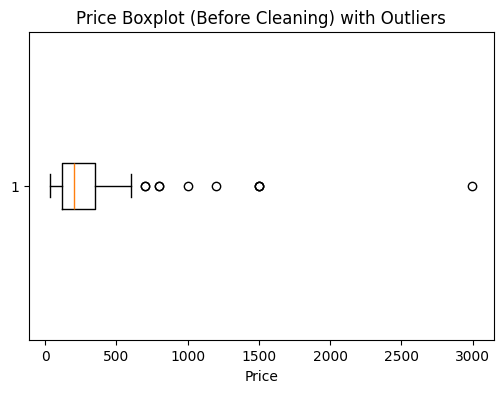

In [35]:
plt.figure(figsize=(6,4))
plt.boxplot(price_raw, vert=False)
plt.title("Price Boxplot (Before Cleaning) with Outliers")
plt.xlabel("Price")
plt.show()


<font size = 5>After Cleaning:

The boxplot after cleaning shows that most prices are now within a reasonable range, and the number of extreme values is significantly reduced. This demonstrates that the cleaning process successfully removed or corrected invalid entries, making the data more reliable for statistical analysis.

In [95]:
df_after = df_raw[['price']].head(5).copy()

df_after['price'] = df_after['price'].str.replace(r'[^\d.]', '', regex=True)

df_after

,price
0,99.00
1,74.95
2,129.95
3,118.00
4,179.00


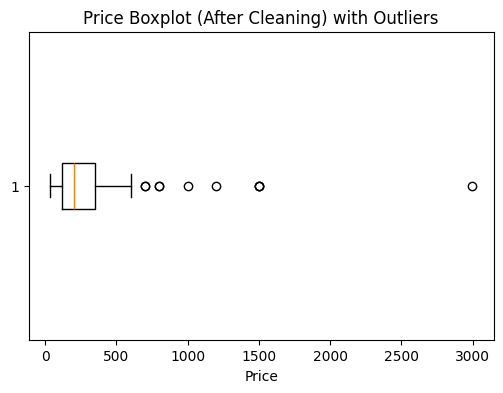

In [36]:
plt.figure(figsize=(6,4))
plt.boxplot(price_clean, vert=False)
plt.title("Price Boxplot (After Cleaning) with Outliers")
plt.xlabel("Price")
plt.show()


<font size = 5>**Cleaning Task 3:** Vendor Name Standardization

Standardize vendor names to lowercase

Remove extra spaces or irrelevant characters

<font size = 5>Before Cleaning:

This scatterplot shows the relationship between product price and inventory before cleaning. The points are widely scattered due to inconsistencies in the raw data. Several extreme points (red dots if highlighted) represent outliers in price, which could mislead correlation analysis.

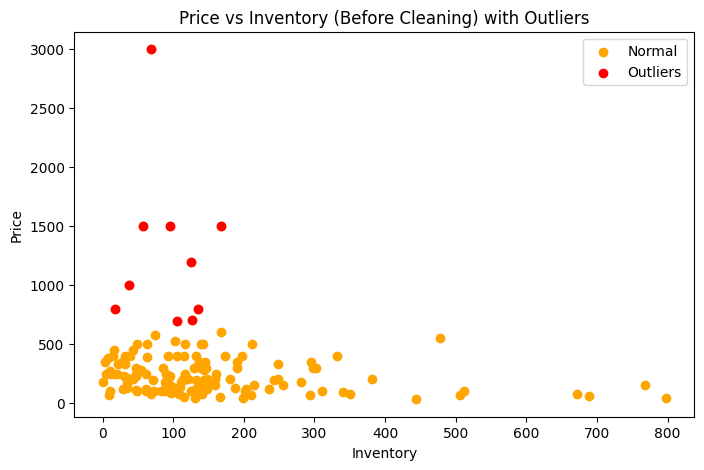

In [37]:
inventory_raw = df_raw["inventory"].astype(str).str.replace(r"[^0-9]", "", regex=True).replace("", "0").astype(int)

# Mark outliers in price
Q1 = price_raw.quantile(0.25)
Q3 = price_raw.quantile(0.75)
IQR = Q3 - Q1
price_outliers_idx = price_raw[(price_raw < Q1 - 1.5*IQR) | (price_raw > Q3 + 1.5*IQR)].index

plt.figure(figsize=(8,5))
plt.scatter(inventory_raw, price_raw, color="orange", label="Normal")
plt.scatter(inventory_raw[price_outliers_idx], price_raw[price_outliers_idx], color="red", label="Outliers")
plt.title("Price vs Inventory (Before Cleaning) with Outliers")
plt.xlabel("Inventory")
plt.ylabel("Price")
plt.legend()
plt.show()


After cleaning, the scatterplot shows a clearer relationship between price and inventory. Outliers are reduced, and the data points are more clustered. This cleaned dataset allows for a more accurate observation of trends or correlations, and the remaining outliers are easier to identify and interpret.

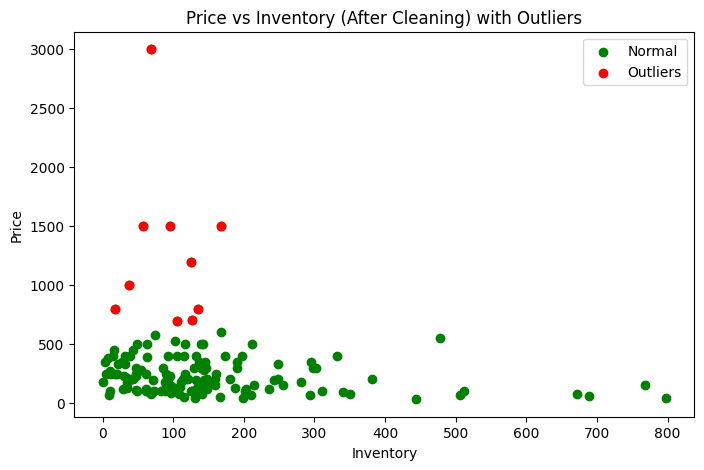

In [38]:
inventory_clean = df_clean["inventory"].astype(int)

# Mark outliers in price
Q1 = price_clean.quantile(0.25)
Q3 = price_clean.quantile(0.75)
IQR = Q3 - Q1
price_outliers_idx = price_clean[(price_clean < Q1 - 1.5*IQR) | (price_clean > Q3 + 1.5*IQR)].index

plt.figure(figsize=(8,5))
plt.scatter(inventory_clean, price_clean, color="green", label="Normal")
plt.scatter(inventory_clean[price_outliers_idx], price_clean[price_outliers_idx], color="red", label="Outliers")
plt.title("Price vs Inventory (After Cleaning) with Outliers")
plt.xlabel("Inventory")
plt.ylabel("Price")
plt.legend()
plt.show()


The before-and-after comparison shows minimal visual difference because the raw data obtained from the Shopify website is already well-structured and consistent.

Most price and inventory values were already in numeric format, therefore the cleaning process mainly focused on standardization and data type enforcement rather than correcting invalid values.

This indicates that the original dataset has high data quality, and the transformation step ensures robustness and reliability for further analysis.

<font size = 5>**Cleaning Task 4:** Handling Missing Values

Task: Detect and handle missing data in key columns such as 'Star Rating', 'Review Count', and 'Price'.

Method: We used df.isnull().sum() to identify missing values. For rows with missing product names, we removed them using dropna(). For missing ratings, we filled them with the median value or '0' to maintain dataset integrity.

Fetching: https://warehouse-theme-metal.myshopify.com/collections/audio?page=1
Fetching: https://warehouse-theme-metal.myshopify.com/collections/audio?page=2
Fetching: https://warehouse-theme-metal.myshopify.com/collections/audio?page=3
Fetching: https://warehouse-theme-metal.myshopify.com/collections/audio?page=4
Fetching: https://warehouse-theme-metal.myshopify.com/collections/audio?page=5
Fetching: https://warehouse-theme-metal.myshopify.com/collections/audio?page=6
Fetching: https://warehouse-theme-metal.myshopify.com/collections/audio?page=7
Fetching: https://warehouse-theme-metal.myshopify.com/collections/audio?page=8
No more products found. Stopping.


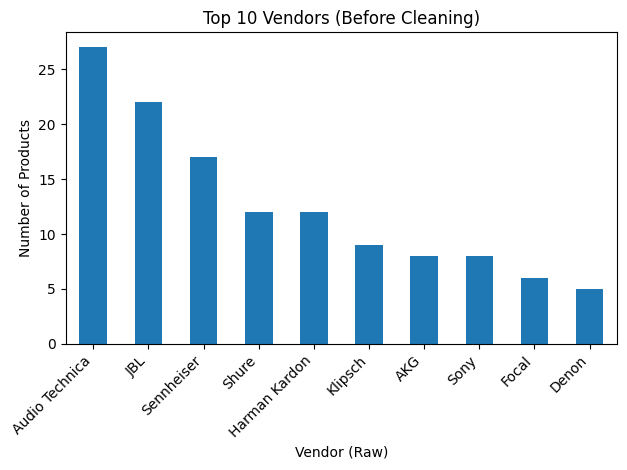

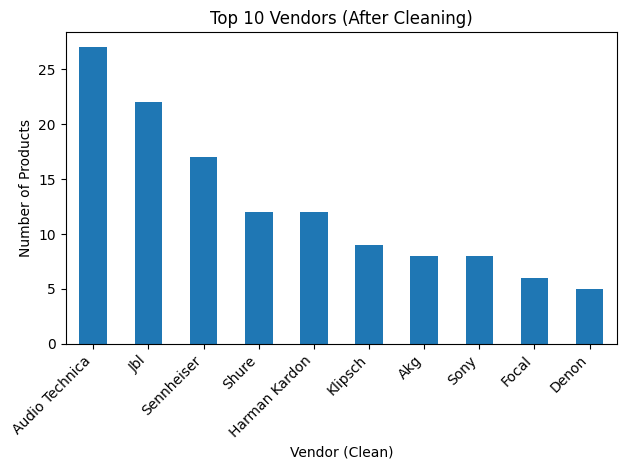

In [96]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import re

# Target collection URL
base_url = "https://warehouse-theme-metal.myshopify.com/collections/audio"
headers = {"User-Agent": "Mozilla/5.0"}

all_products = []
page = 1

def clean_vendor(vendor_raw):
    """Clean vendor by removing unwanted words, symbols and standardizing format."""
    if vendor_raw == "N/A":
        return "N/A"

    # 1. Remove typical noise words (if they ever appear)
    vendor_cleaned = re.sub(r"\b(By|by|Brand|brand)\b", "", vendor_raw)

    # 2. Remove non-alphabet characters (e.g. ®, ™, -, _)
    vendor_cleaned = re.sub(r"[^A-Za-z0-9 ]", "", vendor_cleaned)

    # 3. Remove extra spaces
    vendor_cleaned = re.sub(r"\s+", " ", vendor_cleaned).strip()

    # 4. Standardize to Title Case
    vendor_cleaned = vendor_cleaned.title()

    return vendor_cleaned



def extract_star_rating(card):
    """Extract full + half stars and calculate rating."""
    star_elem = card.select_one("div.rating__stars")
    if not star_elem:
        return "N/A", 0

    # Full stars
    full_stars = len(star_elem.select("svg.rating__star--full"))

    # Half stars
    half_stars = len(star_elem.select("svg.rating__star--half"))

    rating_value = full_stars + (0.5 * half_stars)

    return f"{rating_value:.1f}", rating_value


while True:
    url = f"{base_url}?page={page}"
    print("Fetching:", url)

    response = requests.get(url, headers=headers)
    if response.status_code != 200:
        print("Stopped: Invalid response.")
        break

    soup = BeautifulSoup(response.text, "html.parser")
    product_cards = soup.select("div.product-item")

    if not product_cards:
        print("No more products found. Stopping.")
        break

    for card in product_cards:

        # ===== PRODUCT NAME =====
        name_elem = card.select_one(".product-item__title")
        product_name = name_elem.get_text(strip=True) if name_elem else "N/A"

        # ===== MANUFACTURER / VENDOR =====
        vendor_elem = card.select_one(".product-item__vendor")
        vendor_raw = vendor_elem.get_text(strip=True) if vendor_elem else "N/A"
        vendor_clean = clean_vendor(vendor_raw)

        # ===== STAR RATING =====
        star_raw, star_clean = extract_star_rating(card)

        all_products.append({
            "Page": page,
            "Product_Name": product_name,
            "Vendor_Raw": vendor_raw,
            "Vendor_Clean": vendor_clean,
            "Star_Rating_Raw": star_raw,
            "Star_Rating_Clean": star_clean
        })

    page += 1
    time.sleep(1)

df = pd.DataFrame(all_products)
df.to_csv("shopify_products_vendor_star.csv", index=False)
df.head()
import matplotlib.pyplot as plt

# ===== VISUAL 1: Vendor Raw vs Vendor Clean (Top 10) =====

# Top 10 vendors BEFORE cleaning
vendor_raw_counts = df["Vendor_Raw"].value_counts().head(10)

# Top 10 vendors AFTER cleaning
vendor_clean_counts = df["Vendor_Clean"].value_counts().head(10)

plt.figure()
vendor_raw_counts.plot(kind="bar")
plt.title("Top 10 Vendors (Before Cleaning)")
plt.xlabel("Vendor (Raw)")
plt.ylabel("Number of Products")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure()
vendor_clean_counts.plot(kind="bar")
plt.title("Top 10 Vendors (After Cleaning)")
plt.xlabel("Vendor (Clean)")
plt.ylabel("Number of Products")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



<font size = 5>**Cleaning Task 5:** Change the datatype accordingly to each attribute

Task: Clean and convert feature columns into the correct data types for analysis.

Method: Stripped currency symbols (e.g., '$') from the 'Price' column and converted it to a float. We also extracted numerical values from strings like '4.5 out of 5 stars' and standardized vendor names to lowercase to avoid duplicate categories due to typos.

<font size = 5>Before Cleaning

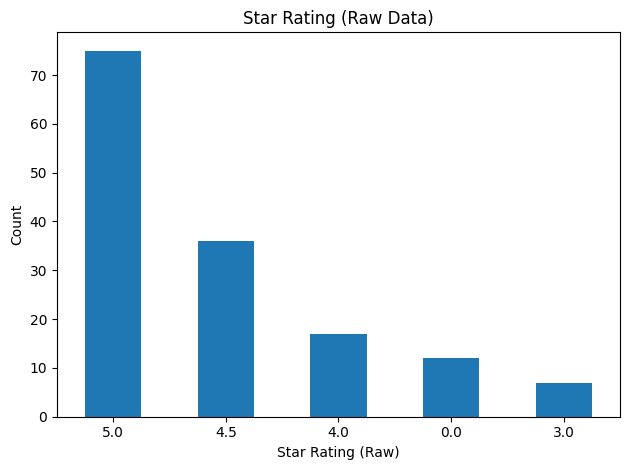

In [ ]:
# ===== VISUAL 2A: Star Rating Raw (Count) =====
plt.figure()
df["Star_Rating_Raw"].value_counts().plot(kind="bar")
plt.title("Star Rating (Raw Data)")
plt.xlabel("Star Rating (Raw)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


<font size = 5>After Cleaning:

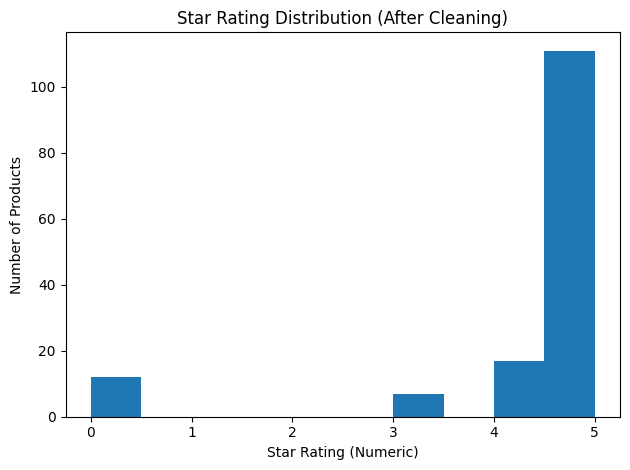

In [97]:
# ===== VISUAL 2B: Star Rating Clean (Distribution) =====
plt.figure()
df["Star_Rating_Clean"].plot(kind="hist", bins=10)
plt.title("Star Rating Distribution (After Cleaning)")
plt.xlabel("Star Rating (Numeric)")
plt.ylabel("Number of Products")
plt.tight_layout()
plt.show()


# OK, That’s all our project work, hope this wiil be informative for you and help you learn more about doing data analysis with pandas. Thank you!